[*********************100%***********************]  1 of 1 completed

Low Vol Threshold: <= 0.006748
High Vol Threshold: > 0.011031

Recent Regime Assignments:


Price,Close,Log_Return,Rolling_Vol,Regime
Ticker,^GSPC,,,
Date,,,,
2023-12-22,4754.629883,0.001659,0.006068,0
2023-12-26,4774.750000,0.004223,0.006007,0
2023-12-27,4781.580078,0.001429,0.006003,0
2023-12-28,4783.350098,0.000370,0.005971,0
2023-12-29,4769.830078,-0.002830,0.006078,0


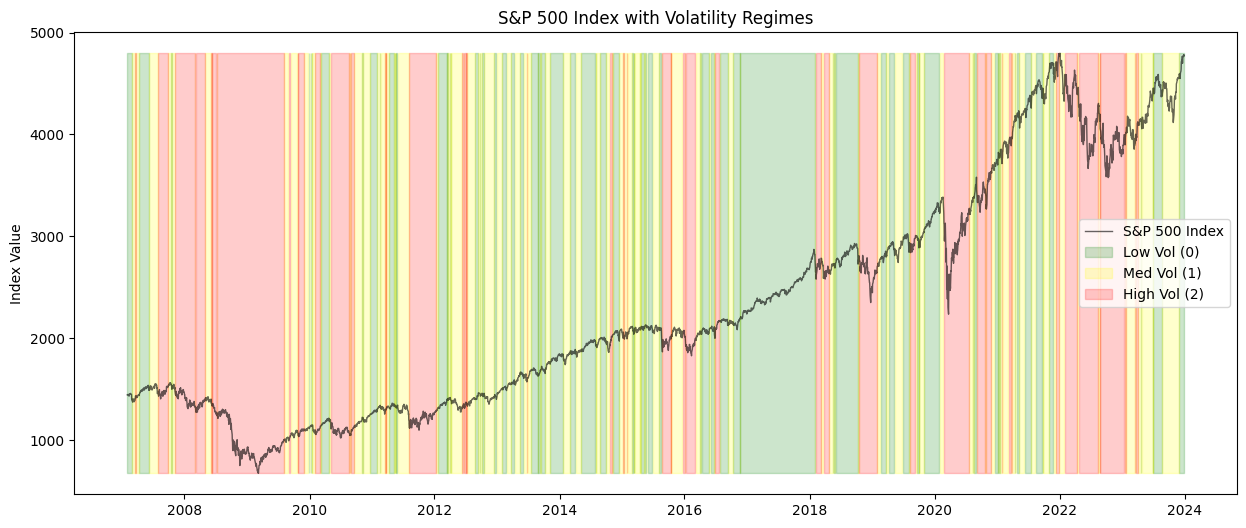

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data = yf.download("^GSPC", start="2007-01-01", end="2024-01-01")

data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

data['Rolling_Vol'] = data['Log_Return'].rolling(window=20).std()
data = data.dropna()


low_threshold = data['Rolling_Vol'].quantile(0.33)
high_threshold = data['Rolling_Vol'].quantile(0.67)

print(f"Low Vol Threshold: <= {low_threshold:.6f}")
print(f"High Vol Threshold: > {high_threshold:.6f}")


def assign_regime(vol):
    if vol <= low_threshold:
        return 0
    elif vol <= high_threshold:
        return 1
    else:
        return 2

data['Regime'] = data['Rolling_Vol'].apply(assign_regime)


print("\nRecent Regime Assignments:")
display(data[['Close', 'Log_Return', 'Rolling_Vol', 'Regime']].tail())


fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(data.index, data['Close'], color='black', lw=1, alpha=0.6, label='S&P 500 Index')

colors = {0: 'green', 1: 'yellow', 2: 'red'}
labels = {0: 'Low Vol (0)', 1: 'Med Vol (1)', 2: 'High Vol (2)'}

for regime in [0, 1, 2]:
    mask = (data['Regime'] == regime)
    ax.fill_between(data.index, data['Close'].min(), data['Close'].max(), 
                    where=mask, color=colors[regime], alpha=0.2, label=labels[regime])

ax.set_title("S&P 500 Index with Volatility Regimes")
ax.set_ylabel("Index Value")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.show()

[*********************100%***********************]  1 of 1 completed


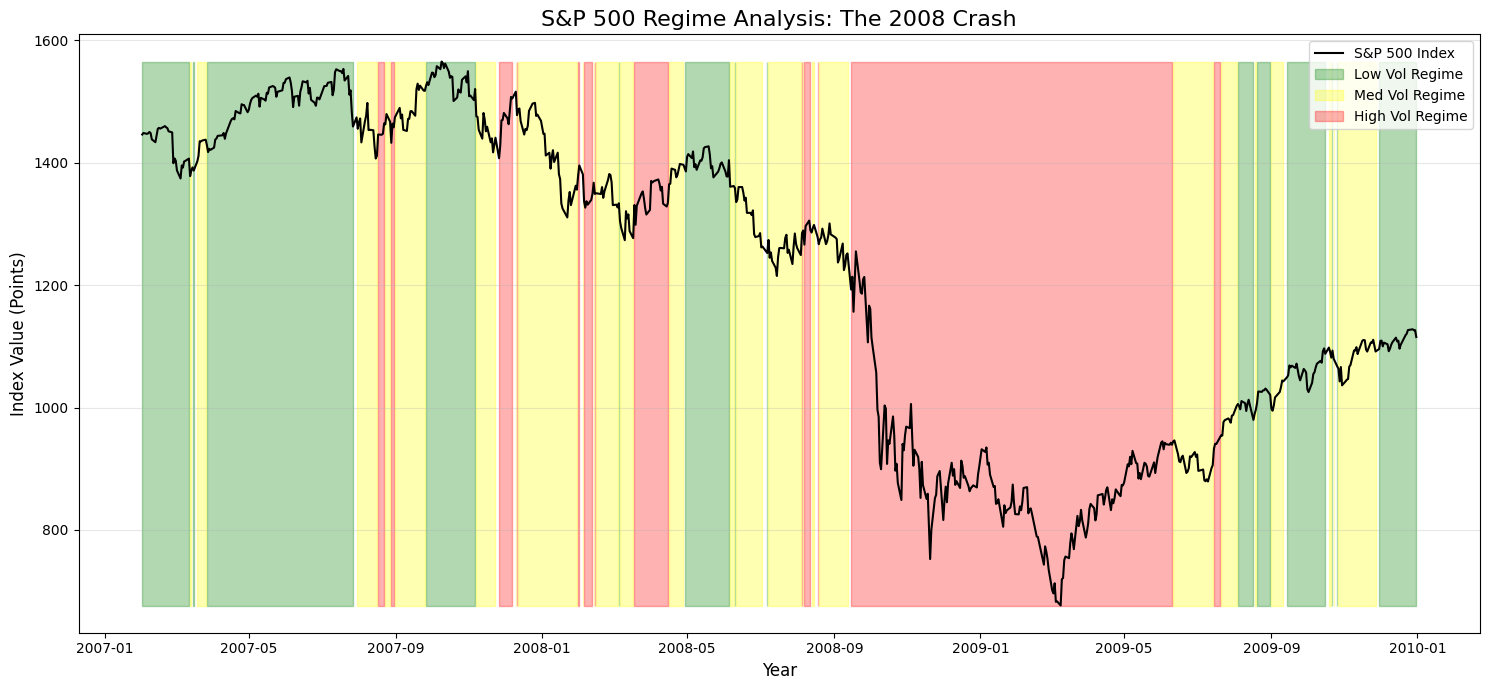

In [9]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fetch Data for the Great Financial Crisis period
# (Start slightly earlier to initialize the 20-day window)
data = yf.download("^GSPC", start="2007-01-01", end="2010-01-01")

# 2. Feature Engineering: Daily Log Returns
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# 3. Calculate 20-Day Rolling Volatility (Standard Deviation of Log Returns)
data['Rolling_Vol'] = data['Log_Return'].rolling(window=20).std()
data = data.dropna()

# 4. Define Thresholds (33rd and 67th percentiles)
low_threshold = data['Rolling_Vol'].quantile(0.33)
high_threshold = data['Rolling_Vol'].quantile(0.67)

# 5. Assign Regimes (0 = Low/Green, 1 = Med/Yellow, 2 = High/Red)
def assign_regime(vol):
    if vol <= low_threshold: return 0
    elif vol <= high_threshold: return 1
    else: return 2

data['Regime'] = data['Rolling_Vol'].apply(assign_regime)

# 6. Plotting (Price Chart Only)
fig, ax = plt.subplots(figsize=(15, 7))

# Plot the S&P 500 Index
ax.plot(data.index, data['Close'], color='black', lw=1.5, label='S&P 500 Index')

# Colors and labels for the background
colors = {0: 'green', 1: 'yellow', 2: 'red'}
labels = {0: 'Low Vol Regime', 1: 'Med Vol Regime', 2: 'High Vol Regime'}

# Fill the background based on the regime
for regime in [0, 1, 2]:
    mask = (data['Regime'] == regime)
    ax.fill_between(data.index, data['Close'].min(), data['Close'].max(), 
                    where=mask, color=colors[regime], alpha=0.3, label=labels[regime])

# Formatting
ax.set_title("S&P 500 Regime Analysis: The 2008 Crash", fontsize=16)
ax.set_ylabel("Index Value (Points)", fontsize=12)
ax.set_xlabel("Year", fontsize=12)

# Handle legend to avoid duplicates
handles, labs = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labs, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed

Plotting from 2025-01-31 to 2026-02-18


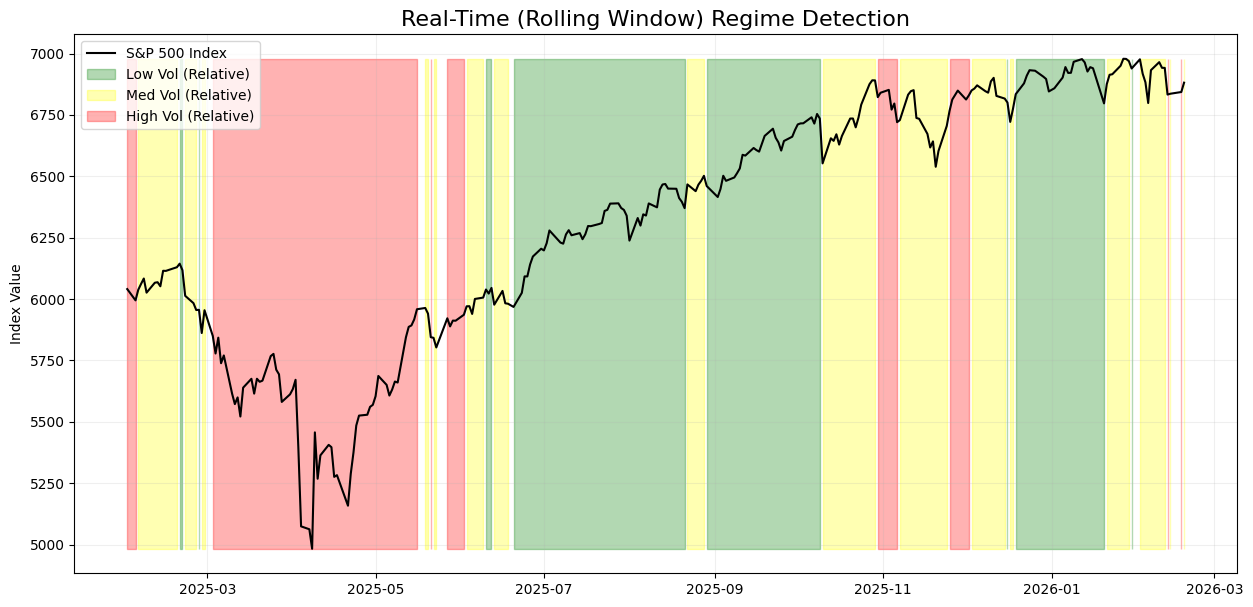

In [11]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fetch Data
# We start in 2024 to give the 252-day rolling window enough 'fuel' to start in 2025
print("Downloading S&P 500 Index data...")
df = yf.download("^GSPC", start="2024-01-01", end="2026-02-19")

# FIX: Flatten MultiIndex columns if they exist (common yfinance issue)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. Calculate Daily Log Returns
# We use .copy() to avoid SettingWithCopy warnings
data = df.copy()
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# 3. 20-Day Current Volatility (Standard Deviation of Log Returns)
data['Current_Vol'] = data['Log_Return'].rolling(window=20).std()

# 4. REAL-TIME THRESHOLDS (The "No-Cheating" Step)
# We use .rolling().quantile() which is much faster and more stable than .apply(lambda)
data['Low_Thresh'] = data['Current_Vol'].rolling(window=252).quantile(0.33)
data['High_Thresh'] = data['Current_Vol'].rolling(window=252).quantile(0.67)

# 5. Assign Regimes (0=Low, 1=Med, 2=High)
# Using np.select is the fastest and most error-proof way to assign labels
conditions = [
    (data['Current_Vol'] <= data['Low_Thresh']),
    (data['Current_Vol'] > data['Low_Thresh']) & (data['Current_Vol'] <= data['High_Thresh']),
    (data['Current_Vol'] > data['High_Thresh'])
]
values = [0, 1, 2]
data['Regime'] = np.select(conditions, values, default=np.nan)

# Drop rows where we don't have enough data yet for the rolling windows
data = data.dropna(subset=['Regime'])

# 6. Plotting
print(f"Plotting from {data.index.min().date()} to {data.index.max().date()}")
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(data.index, data['Close'], color='black', lw=1.5, label='S&P 500 Index')

colors = {0: 'green', 1: 'yellow', 2: 'red'}
labels = {0: 'Low Vol (Relative)', 1: 'Med Vol (Relative)', 2: 'High Vol (Relative)'}

for r_val, r_color in colors.items():
    mask = (data['Regime'] == r_val)
    ax.fill_between(data.index, data['Close'].min(), data['Close'].max(), 
                    where=mask, color=r_color, alpha=0.3, label=labels[r_val])

ax.set_title("Real-Time (Rolling Window) Regime Detection", fontsize=16)
ax.set_ylabel("Index Value")

# Remove duplicate labels in legend
handles, labs = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labs, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.grid(alpha=0.2)
plt.show()